<a href="https://colab.research.google.com/github/myasym/carisurg-portfolio/blob/feat%2Fweekly-updates/notebooks/03_baseline_model/Week6_Baseline_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6: Baseline Triage Models

**CariSurg MedTech Pathways**
**Mercer General Emergency Department**
**Dataset:** Yale EMMLC (cleaned)

**Objective:** Develop and evaluate two clinically interpretable baseline classifiers, logistic regression and a decision tree, and compare their performance with a stratified random baseline, following Dr. De Fretias's project brief.

**Reproducibility:** A fixed random seed (`RANDOM_STATE = 42`) was used throughout the notebook.


In [18]:
# Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score, precision_score, accuracy_score
)

RANDOM_STATE = 42
pd.set_option("display.width", 120)
print("Libraries loaded.")

Libraries loaded.


## 1. Load the Cleaned Dataset

Load `triage_cleaned_v1.csv` from Week 5. The dataset was preprocessed and contains no missing values, as documented in the feasibility memo.


In [19]:
from pathlib import Path
from google.colab import drive; drive.mount("/content/drive")
DATA_PATH = "/content/drive/MyDrive/CariSurg/triage_cleaned_v1.csv"
df = pd.read_csv(DATA_PATH)
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 55121 patients and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Define Target and Remove Leakage Variables

The target variable, `TARGET`, represents the Emergency Severity Index (ESI) level assigned by the triage nurse, ranging from 1 to 5, with 1 indicating the highest urgency. Variables only available after the triage process, such as disposition, were removed to prevent data leakage and ensure realistic model performance during deployment.


In [20]:
TARGET = "esi"
LEAKAGE = ["disposition", "previousdispo"]  # known only after triage not to be used as features
NON_NUMERIC = [c for c in df.select_dtypes(include="object").columns if c != TARGET]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE and c not in NON_NUMERIC]
X = df[FEATURES]
y = df[TARGET]
print(f"Using {len(FEATURES)} features to predict '{TARGET}'.")
print("Class distribution:\n", y.value_counts(normalize=True).sort_index().round(3))

Using 210 features to predict 'esi'.
Class distribution:
 esi
1    0.001
2    0.325
3    0.490
4    0.161
5    0.022
Name: proportion, dtype: float64


## 3. Train/Test Split: 80/20 Stratified Split

The dataset was divided into training and testing sets using an 80/20 stratified split. Stratification ensured that the less common ESI-1 class remained represented in both sets. The use of `random_state=RANDOM_STATE` (42) ensured that the split was reproducible across different environments.


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 44096 | Test: 11025


## 4. Scale Features for Logistic Regression

Feature scaling was applied for logistic regression because the model uses weighted feature contributions. Scaling prevents variables with larger numerical ranges from dominating those with smaller ranges. The scaler was fitted only on the training data and then applied to the test data to prevent data leakage and maintain unbiased evaluation. Decision tree models do not require feature scaling because they make decisions based on feature comparisons.

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5 · Baseline to beat - stratified DummyClassifier
Guesses ESI levels at random, in the same proportions as the true distribution. If our real models can't clear this bar, they add no clinical value.

In [23]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
print("Dummy accuracy:", round(accuracy_score(y_test, pred_dummy), 4))

Dummy accuracy: 0.3754


## 6. Model 1: Logistic Regression

A logistic regression classifier was trained using the scaled feature set. This model was selected as an interpretable baseline that estimates the relationship between patient features and ESI level classification.


In [24]:
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)
print("Logistic Regression accuracy:", round(accuracy_score(y_test, pred_logreg), 4))

Logistic Regression accuracy: 0.6826


## 7. Model 2: Decision Tree

A decision tree classifier was trained using a maximum depth of 5. This limit was applied to maintain clinical interpretability by ensuring that decision paths remained understandable while still capturing relevant patterns in the data. An unrestricted tree was avoided to reduce overfitting and improve suitability for clinical review.


In [25]:
tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Decision Tree accuracy:", round(accuracy_score(y_test, pred_tree), 4))

Decision Tree accuracy: 0.5475


## 8. Per-Class Evaluation Metrics

Accuracy, precision, recall, and F1-score were calculated for each ESI level. The F1-score is a measure that combines precision and recall into a single value, providing a balanced assessment of model performance. Evaluating individual classes is important because an overall performance score may hide poor performance on rare and clinically important classes, such as ESI-1.


In [26]:
print("=== Logistic Regression — per-class report ===")
print(classification_report(y_test, pred_logreg, digits=3))
print("\n=== Decision Tree — per-class report ===")
print(classification_report(y_test, pred_tree, digits=3))

=== Logistic Regression — per-class report ===
              precision    recall  f1-score   support

           1      0.444     0.250     0.320        16
           2      0.735     0.625     0.676      3585
           3      0.676     0.770     0.720      5402
           4      0.623     0.613     0.618      1779
           5      0.509     0.119     0.193       243

    accuracy                          0.683     11025
   macro avg      0.597     0.476     0.505     11025
weighted avg      0.682     0.683     0.677     11025


=== Decision Tree — per-class report ===
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.792     0.233     0.360      3585
           3      0.522     0.963     0.677      5402
           4      0.000     0.000     0.000      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.547     11025
   macro avg      0.263     0.239     0.20

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 9. Confusion Matrices

Confusion matrices were used to visualise model predictions across ESI levels. Rows represent the true ESI levels, while columns represent the predicted ESI levels. Values along the diagonal indicate correctly classified cases. Labels were displayed using the actual ESI values (1 to 5) rather than raw array indices.


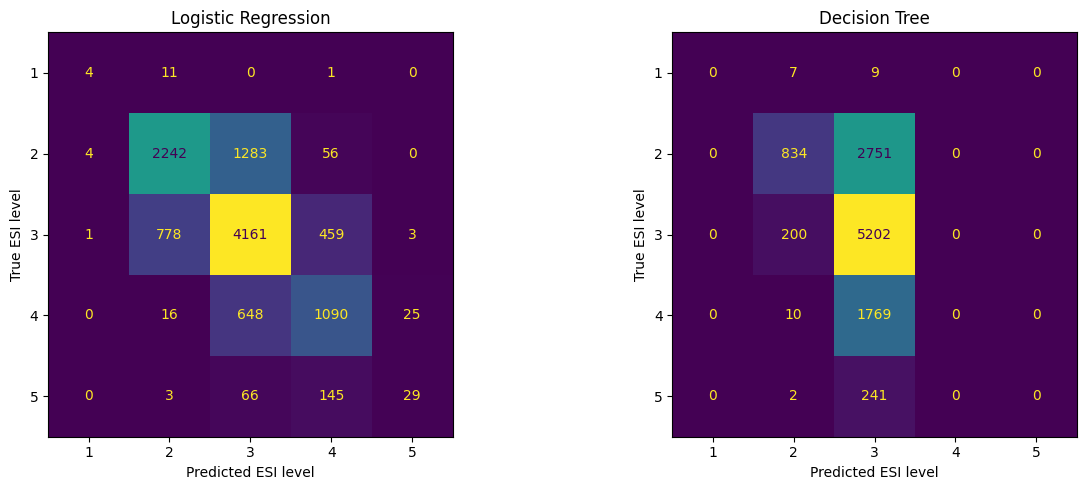

Saved ../docs/w6_confusion_matrices.png


In [27]:
os.makedirs("../docs", exist_ok=True)
esi_labels = sorted(y.unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_logreg, labels=esi_labels, ax=axes[0], colorbar=False
)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted ESI level")
axes[0].set_ylabel("True ESI level")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_tree, labels=esi_labels, ax=axes[1], colorbar=False
)
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted ESI level")
axes[1].set_ylabel("True ESI level")

plt.tight_layout()
plt.savefig("../docs/w6_confusion_matrices.png", dpi=110)
plt.show()
print("Saved ../docs/w6_confusion_matrices.png")

## 10. Benchmark Comparison Table

A comparison table was created to evaluate all models using the same performance metrics alongside the dummy baseline. The recall score for ESI-1 was given particular attention, as it represents the model's ability to correctly identify the highest urgency cases.

In [28]:
def summarise(name, preds):
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_test, preds), 3),
        "macro_F1": round(f1_score(y_test, preds, average="macro"), 3),
        "weighted_F1": round(f1_score(y_test, preds, average="weighted"), 3),
        "recall_ESI1": round(recall_score(y_test, preds, labels=[1], average=None)[0], 3)
        if 1 in esi_labels else float("nan"),
    }

benchmark = pd.DataFrame([
    summarise("Dummy (baseline)", pred_dummy),
    summarise("Logistic Regression", pred_logreg),
    summarise("Decision Tree", pred_tree),
])
benchmark

,model,accuracy,macro_F1,weighted_F1,recall_ESI1
0,Dummy (baseline),0.375,0.204,0.375,0.00
1,Logistic Regression,0.683,0.505,0.677,0.25
2,Decision Tree,0.547,0.207,0.449,0.00


## 11 · Metric justification
Neither baseline model met the requirements for clinical deployment. The decision tree failed to identify any critical ESI-1 patients, while logistic regression performed better but still missed approximately 75% of these cases. This limitation is the key finding of the baseline evaluation and is more important than the overall accuracy score.

Recall for ESI-1 was prioritised because accuracy can mask poor performance on rare but clinically important classes. ESI-3 represented 49% of the dataset, whereas ESI-1 represented only 0.1% (16 patients in the test set). As a result, a model can achieve reasonable overall accuracy while failing to identify critical patients. The decision tree achieved 68.3% accuracy but had 0% recall for ESI-1. Logistic regression achieved a higher ESI-1 recall of 25% (4 of 16 patients), but this remains insufficient for a clinical triage system.

For a triage application, failing to identify an ESI-1 patient is more serious than incorrectly flagging a lower-risk patient. Therefore, recall is a more appropriate primary metric than accuracy for this task. Due to the small number of ESI-1 cases in the test set, these recall estimates should be interpreted cautiously, as individual cases have a large effect on the reported performance.

## 12 · Failure mode reflection

**Which group does the model miss most?**
Both models most frequently missed ESI-1 patients, who represent the highest severity category. The decision tree also failed to identify ESI-4 and ESI-5 cases, predicting only the two majority classes, ESI-2 and ESI-3.

**Why?**
This pattern is likely due to severe class imbalance within the dataset. ESI-1 cases represent only 0.1% of the data, creating a large difference in representation compared with ESI-3 cases. Combined with the limited depth of the decision tree, this imbalance likely caused the models to favour majority classes rather than learning meaningful patterns for rare classes.

**So what?**
As a result, these baseline models may under-triage the most critical patients by assigning them lower urgency levels. This represents a significant safety concern for a clinical triage system, and neither model is suitable for deployment in its current form.

**Next step?**
The next step is to address class imbalance using methods such as class weighting or resampling. These findings show that basic logistic regression and decision tree models are insufficient without further adaptation for this clinical application.